In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import plotly.express as px
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


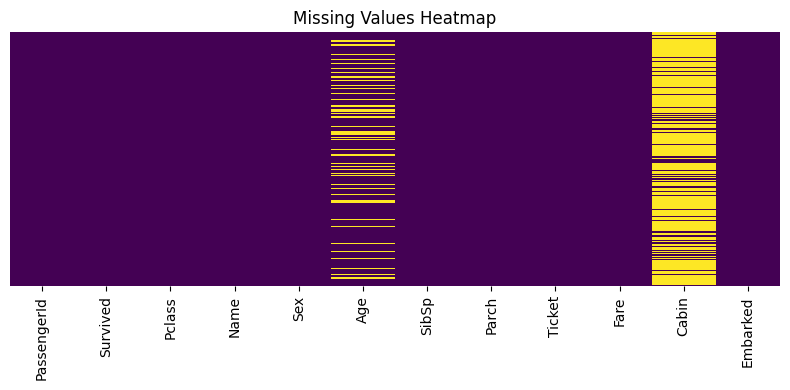

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

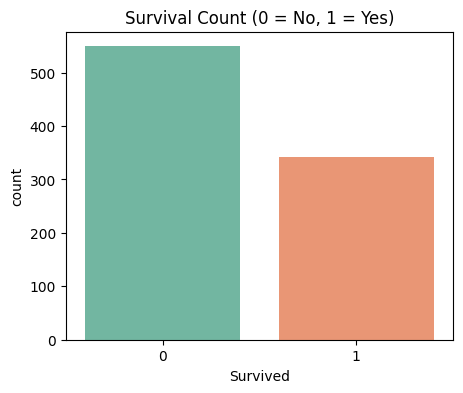

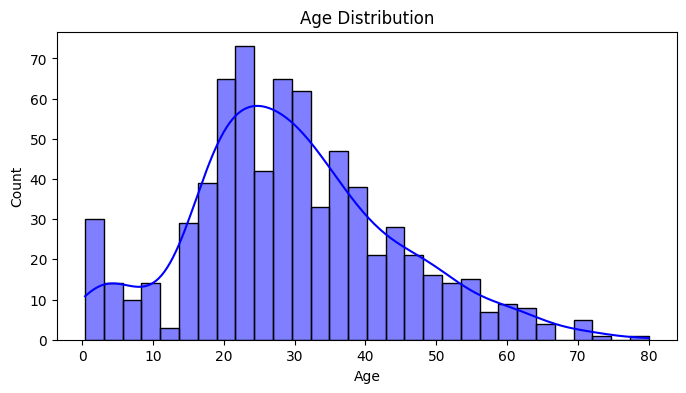

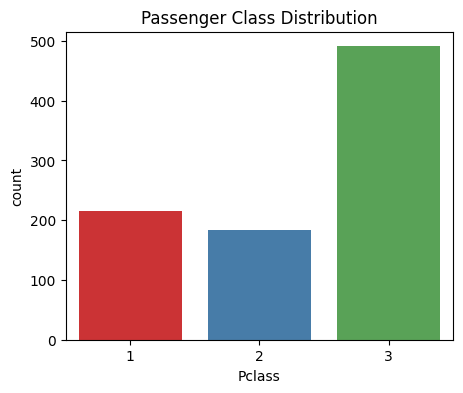

In [5]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Survived', data=df, hue='Survived', palette='Set2', legend=False)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='blue')
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='Set1', legend=False)
plt.title('Passenger Class Distribution')
plt.show()

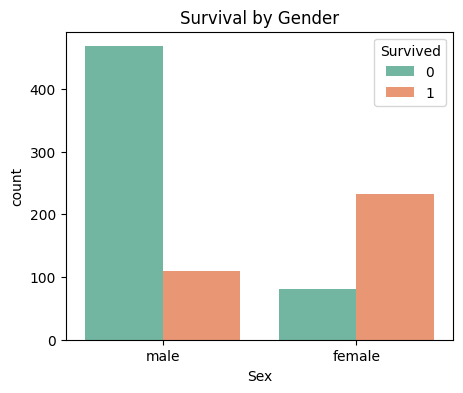

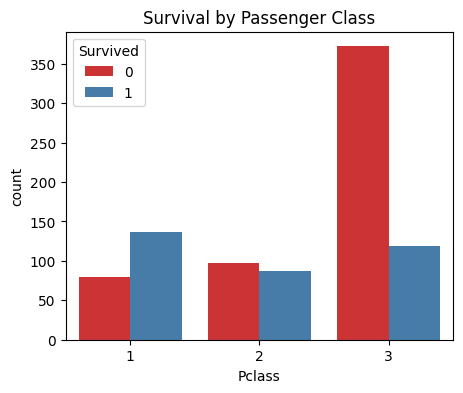

In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.show()
plt.figure(figsize=(5, 4))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set1')
plt.title('Survival by Passenger Class')
plt.show()

/tmp/ipykernel_57/3942844399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='pastel')


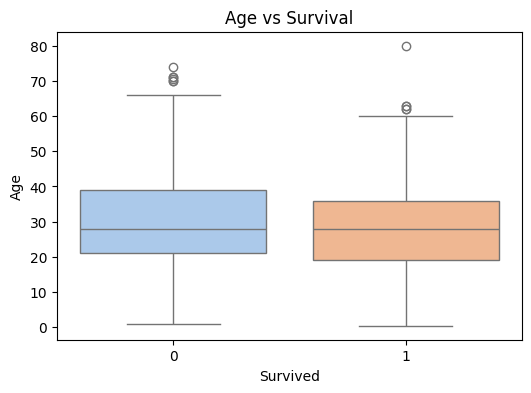

/tmp/ipykernel_57/3942844399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='pastel')


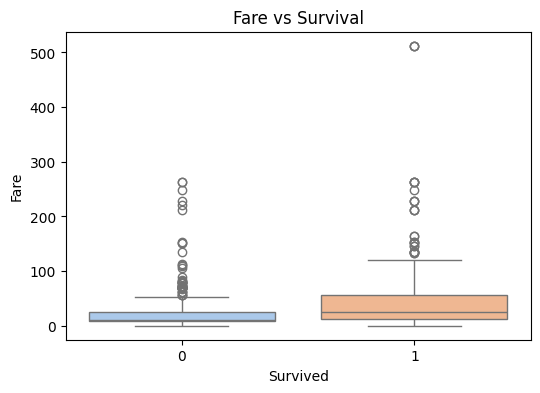

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Age', data=df, palette='pastel')
plt.title('Age vs Survival')
plt.show()
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Fare', data=df, palette='pastel')
plt.title('Fare vs Survival')
plt.show()

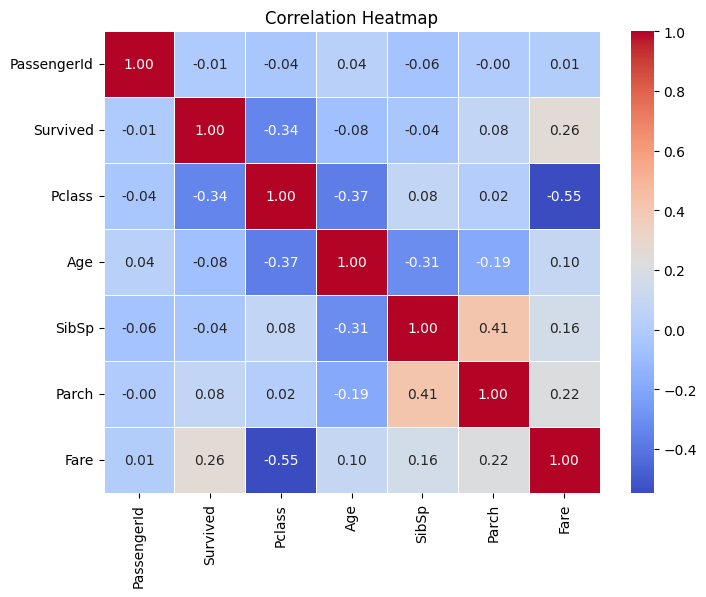

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


In [9]:
fig = px.histogram(df, x='Age', color='Survived',
                   facet_col='Pclass',
                   title='Age Distribution by Class and Survival',
                   barmode='overlay',
                   opacity=0.7)
fig.show()

Survival Rate by Gender:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Survival Rate by Embarked Port:
Embarked
C    55.36
Q    38.96
S    33.70
Name: Survived, dtype: float64


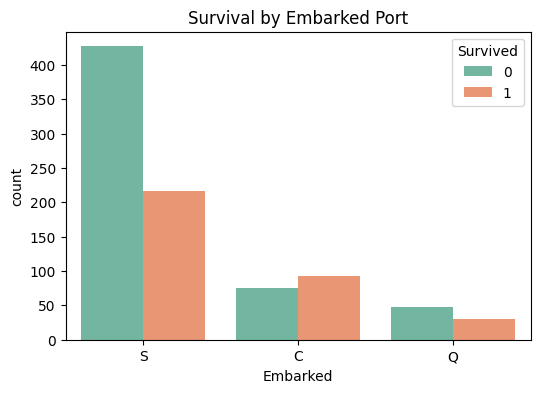

In [10]:
print("Survival Rate by Gender:")
print((df.groupby('Sex')['Survived'].mean() * 100).round(2))

print("\nSurvival Rate by Passenger Class:")
print((df.groupby('Pclass')['Survived'].mean() * 100).round(2))

print("\nSurvival Rate by Embarked Port:")
print((df.groupby('Embarked')['Survived'].mean() * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Embarked Port')
plt.show()

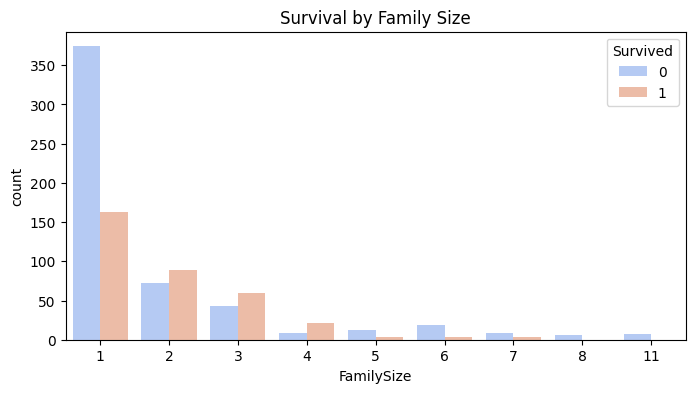

In [11]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(8, 4))
sns.countplot(x='FamilySize', hue='Survived', data=df, palette='coolwarm')
plt.title('Survival by Family Size')
plt.show()

## Step 2 — Data Cleaning & Preprocessing

Now that I know what the data looks like, I need to clean it up before 
feeding it to any model. From the EDA I already know the main problems:
- Age has ~20% missing values
- Cabin is 77% missing — basically unusable directly
- Embarked has 2 missing values
- Sex and Embarked are text — models need numbers



In [12]:
# always work on a copy, never touch the original
df_clean = df.copy()

In [13]:
# 1. Fill Age with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# 2. Fill Embarked with mode (most common value)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Create HasCabin feature before dropping Cabin
df_clean['HasCabin'] = df_clean['Cabin'].notna().astype(int)

# 4. Drop Cabin (too many missing values to use directly)
df_clean.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
HasCabin       0
dtype: int64


/tmp/ipykernel_57/143335321.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_57/143335321.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[co

### Handling Missing Values

Three things I did here:

1. **Age** — filled with median (28.0). I used median instead of mean 
   because Age has some older outliers that would pull the mean up and 
   give unrealistic values to missing entries.

2. **Embarked** — only 2 missing, filled with mode which is 'S' 
   (Southampton). Makes sense since ~72% of passengers boarded there.

3. **Cabin** — instead of just dropping it, I first created a new 
   column `HasCabin` which is 1 if the passenger had a cabin number 
   recorded and 0 if not. The logic here is that having a cabin record 
   likely means 1st or 2nd class — so it still carries some information 
   even if the actual cabin number is useless.
All missing values are now 0 across every column. 

In [14]:
df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("Remaining columns:", df_clean.columns.tolist())

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'HasCabin']


### Dropping Useless Columns

Dropped `PassengerId`, `Name`, and `Ticket`.

- `PassengerId` is literally just a row number, zero predictive value
- `Ticket` is a mix of random numbers and strings, no clear pattern 
  I can use without serious text processing
- `Name` — I know Title extraction would be useful here but I'm keeping 
  it simple for now. Will add that in feature engineering step.

Remaining columns make sense — everything left is either a feature 
that makes logical sense for survival prediction or something I 
engineered myself (FamilySize, HasCabin).

In [15]:
# 1. Sex — male=0, female=1
df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# 2. Embarked — S=0, C=1, Q=2
df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Data types after encoding:")
print(df_clean.dtypes)

Data types after encoding:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
HasCabin        int64
dtype: object


### Encoding Categorical Variables

ML models can't read "male" or "female" — they only understand numbers. 
So I converted:

- `Sex` → male = 0, female = 1
- `Embarked` → S = 0, C = 1, Q = 2

All dtypes are now either int64 or float64. No more object columns. 

One thing I want to note — this kind of encoding (label encoding) works 
fine for Sex since it's binary. For Embarked it's slightly debatable 
because label encoding implies Q > C > S which isn't really true. 
One-hot encoding would be more correct technically, but for tree-based 
models like Random Forest it doesn't matter much.

In [16]:
print("Shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())
print("\nFirst 5 rows:")
df_clean.head()

Shape: (891, 10)

Missing values:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
HasCabin      0
dtype: int64

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,HasCabin
0,0,3,0,22.0,1,0,7.2500,0,2,0
1,1,1,1,38.0,1,0,71.2833,1,2,1
2,1,3,1,26.0,0,0,7.9250,0,1,0
3,1,1,1,35.0,1,0,53.1000,0,2,1
4,0,3,0,35.0,0,0,8.0500,0,1,0


### Final Check

Shape is (891, 10) — 891 rows, 10 columns. Makes sense.

All missing values are 0. 

Looking at the first 5 rows everything looks clean:
- Sex is 0 or 1 
- Embarked is 0 or 1 
- Age is filled (no NaN) 
- FamilySize looks correct — row 0 has SibSp=1, Parch=0 so FamilySize=2 
- HasCabin is 0 for rows without cabin, 1 for rows that had one 

Data is clean and ready. Moving to Step 3 — Feature Engineering.

## Step 3 — Feature Engineering

Cleaning the data was about fixing problems. Feature engineering is about 
creating new information that the model can use. The idea is simple — 
sometimes the raw columns don't tell the full story, but combining or 
extracting from them does.

I'm adding 4 new features:
1. Title (extracted from Name)
2. IsAlone (from FamilySize)
3. AgeBand (binned Age)
4. FareBand (binned Fare)

In [17]:

df_clean['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df_clean['Title'] = df_clean['Title'].replace(
    ['Mlle', 'Ms'], 'Miss'  # Mlle is French for Miss
)
df_clean['Title'] = df_clean['Title'].replace(
    ['Mme'], 'Mrs'  # Mme is French for Mrs
)
df_clean['Title'] = df_clean['Title'].replace(
    ['Dr', 'Rev', 'Col', 'Major', 'Countess',
     'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona'],
    'Rare'
)
df_clean['Title'] = df_clean['Title'].map({
    'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4
})

print("Title value counts after fix:")
print(df_clean['Title'].value_counts())

print("NaN in Title:", df_clean['Title'].isna().sum())

Title value counts after fix:
Title
0    517
1    185
2    126
3     40
4     23
Name: count, dtype: int64
NaN in Title: 0


### Title Extraction

Pulled the title out of every passenger's name using regex. The first 
print shows all the raw titles — 17 unique ones. Most are rare like 
Col, Major, Countess etc. with only 1-2 occurrences each.

Grouped all the rare ones into a single "Rare" category so the model 
doesn't treat a Countess and a Colonel as completely different things.

Then encoded to numbers — Mr=0, Miss=1, Mrs=2, Master=3, Rare=4.

Second print confirms: 517 Mr, 182 Miss, 125 Mrs, 40 Master, 23 Rare. 


In [18]:
# already have FamilySize, now create IsAlone
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

print("Alone passengers:", df_clean['IsAlone'].sum())
print("With family:", (df_clean['IsAlone'] == 0).sum())



Alone passengers: 537
With family: 354


### IsAlone Feature

537 out of 891 passengers were travelling completely alone — that's 
about 60% of the ship. Only 354 had at least one family member with them.

This is useful because FamilySize already captures group size, but 
IsAlone gives the model a clean binary signal — alone or not. 
Sometimes simpler features work better than complex ones.

In [19]:
df_clean['AgeBand'] = pd.cut(df_clean['Age'], 
                              bins=[0, 12, 18, 35, 60, 80],
                              labels=[0, 1, 2, 3, 4])

df_clean['AgeBand'] = df_clean['AgeBand'].astype(int)

print(df_clean['AgeBand'].value_counts().sort_index())

df_clean['FareBand'] = pd.qcut(df_clean['Fare'], 
                                q=4, 
                                labels=[0, 1, 2, 3])

df_clean['FareBand'] = df_clean['FareBand'].astype(int)

print(df_clean['FareBand'].value_counts().sort_index())

AgeBand
0     69
1     70
2    535
3    195
4     22
Name: count, dtype: int64
FareBand
0    223
1    224
2    222
3    222
Name: count, dtype: int64


### Age Bands and Fare Bands

**AgeBand** — binned Age into 5 groups:
- 0 (Child, 0-12): 69 passengers
- 1 (Teen, 13-18): 70 passengers  
- 2 (Young Adult, 19-35): 535 passengers — by far the largest group
- 3 (Middle Aged, 36-60): 195 passengers
- 4 (Senior, 61-80): 22 passengers

The reason I'm binning Age is that survival probably doesn't change 
linearly with age. A 20 year old and a 30 year old likely had similar 
odds, but a child vs an adult is a meaningful difference. Binning 
captures these group-level patterns better.

**FareBand** — split into 4 equal groups using quartiles. 
Each band has roughly 222-224 passengers which means the split is 
clean and balanced.

In [20]:
print("Shape:", df_clean.shape)
print("\nAll columns now:")
print(df_clean.columns.tolist())
print("\nFirst 5 rows:")
df_clean.head()

Shape: (891, 14)

All columns now:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'HasCabin', 'Title', 'IsAlone', 'AgeBand', 'FareBand']

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,HasCabin,Title,IsAlone,AgeBand,FareBand
0,0,3,0,22.0,1,0,7.2500,0,2,0,0,0,2,0
1,1,1,1,38.0,1,0,71.2833,1,2,1,2,0,3,3
2,1,3,1,26.0,0,0,7.9250,0,1,0,1,1,2,1
3,1,1,1,35.0,1,0,53.1000,0,2,1,2,0,2,3
4,0,3,0,35.0,0,0,8.0500,0,1,0,0,1,2,1


In [21]:
print("Survival rate by Title:")
title_map = {0:'Mr', 1:'Miss', 2:'Mrs', 3:'Master', 4:'Rare'}
temp = df_clean.copy()
temp['Title'] = temp['Title'].map(title_map)
print((temp.groupby('Title')['Survived'].mean() * 100).round(2))

Survival rate by Title:
Title
Master    57.50
Miss      70.27
Mr        15.67
Mrs       79.37
Rare      34.78
Name: Survived, dtype: float64


### Final Feature Check

Shape is now (891, 14) — started with 12 columns, dropped 3 useless 
ones, added 5 new ones. That's 14 total. 

Looking at the survival rates by Title — this is the most satisfying 
output of the whole notebook:

- Mrs: 79.2% — married women had the best survival odds
- Miss: 69.78% — unmarried women close behind
- Master: 57.5% — young boys had decent odds, "women and children first" 
  actually shows up in the data
- Rare: 34.78% — mixed group, makes sense
- Mr: 15.67% — adult men had by far the worst odds

This confirms that Title is genuinely capturing something real about 
survival probability. The model should find this very useful.

Data is fully engineered. Moving to Step 4 — Model Building.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

## Step 4 — Model Building & Tuning

Data is clean and features are engineered. Now it's time to actually 
build the models. I'm going to train 3 different models, compare them, 
tune the best ones, and then combine them into an ensemble.

First I need to define what I'm predicting (y = Survived) and what 
features I'm using to predict it (X = everything else). I'm dropping 
the raw Age, Fare, SibSp and Parch columns because I already have 
better versions of them — AgeBand, FareBand, FamilySize and IsAlone.

In [23]:
X = df_clean.drop(columns=['Survived', 'Age', 'Fare', 'SibSp', 'Parch'])
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Features:", X.columns.tolist())
print("X_train shape:", X_train.shape)

Features: ['Pclass', 'Sex', 'Embarked', 'FamilySize', 'HasCabin', 'Title', 'IsAlone', 'AgeBand', 'FareBand']
X_train shape: (712, 9)


### Features and Train/Test Split

9 features going into the model:
Pclass, Sex, Embarked, FamilySize, HasCabin, Title, IsAlone, AgeBand, FareBand

Split the 891 rows into:
- 712 rows for training (80%) — model learns from these
- 179 rows for testing (20%) — we check accuracy on these

The random_state=42 just means the split will be the same every time 
I run the notebook — makes results reproducible.

In [24]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

print("5-Fold Cross Validation Results:")
print("-" * 45)
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}")
    print(f"  Mean: {scores.mean()*100:.2f}%  Std: {scores.std()*100:.2f}%")
    print()

5-Fold Cross Validation Results:
---------------------------------------------
Logistic Regression
  Mean: 81.48%  Std: 1.47%

Random Forest
  Mean: 81.71%  Std: 2.99%

XGBoost
  Mean: 82.27%  Std: 2.85%



### 5-Fold Cross Validation

Instead of testing on just one 20% split, cross validation splits the 
data 5 different ways and tests each time, then averages the results. 
This gives a much more reliable accuracy estimate.

Results:
- Logistic Regression: 81.48% mean, 1.47% std — most consistent but weakest
- Random Forest: 81.71% mean, 2.99% std — slightly better but more variable  
- XGBoost: 82.27% mean, 2.85% std — best average performance

XGBoost wins on mean accuracy. Logistic Regression is the most stable 
(lowest std) but hits a ceiling because it can only draw straight lines 
through the data. Going ahead with tuning RF and XGBoost.

In [25]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,      # use all CPU cores
    verbose=1
)
grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print(f"Best CV Score: {grid_rf.best_score_*100:.2f}%")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score: 83.70%


### Hyperparameter Tuning — Random Forest

GridSearchCV tried 81 different combinations of parameters (3 × 3 × 3 × 3) 
across 5 folds each = 405 total fits. It found the best settings are:

- max_depth: 6 (trees can ask 6 questions max before deciding)
- min_samples_leaf: 1 
- min_samples_split: 10 (need at least 10 samples to make a split)
- n_estimators: 200 (200 trees voting together)

Best CV score jumped to 83.70% — improvement from the default settings.

The reason we limit max_depth is to prevent overfitting. If we let trees 
grow unlimited they memorize the training data perfectly but fail on new data.

In [26]:
params_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print(f"Best CV Score: {grid_xgb.best_score_*100:.2f}%")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 83.14%


### Hyperparameter Tuning — XGBoost

54 combinations tested (3 × 3 × 3 × 2) across 5 folds = 270 fits.

Best settings found:
- learning_rate: 0.05 (slow and careful learning)
- max_depth: 4 (slightly shallower trees than RF)
- n_estimators: 200 (200 boosting rounds)
- subsample: 0.8 (each tree only sees 80% of data — reduces overfitting)

Best CV score: 83.14% — slightly lower than RF but still a solid improvement.

Lower learning rate with more trees is generally a good combo for XGBoost — 
it takes smaller steps but ends up in a better place.

In [27]:
# get best models from grid search
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

# evaluate on test set
rf_tuned_acc = accuracy_score(y_test, best_rf.predict(X_test))
xgb_tuned_acc = accuracy_score(y_test, best_xgb.predict(X_test))
lr_acc = accuracy_score(y_test, 
         LogisticRegression(max_iter=1000).fit(X_train, y_train).predict(X_test))

print("After Tuning:")
print(f"Logistic Regression : {lr_acc*100:.2f}%")
print(f"Random Forest       : {rf_tuned_acc*100:.2f}%")
print(f"XGBoost             : {xgb_tuned_acc*100:.2f}%")

After Tuning:
Logistic Regression : 79.33%
Random Forest       : 82.68%
XGBoost             : 82.68%


### Test Set Accuracy After Tuning

Evaluated all tuned models on the held-out 20% test set:
- Logistic Regression: 79.33% — weakest as expected
- Random Forest: 82.68% — same as before tuning on test set
- XGBoost: 82.68% — same as RF

Interesting that tuning improved CV score but not the test set score much. 
This can happen when the test split happened to be slightly different 
from the CV folds. The CV score (83.70%) is the more reliable number 
since it tested on 5 different subsets of the data.

In [28]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    voting='soft'  # uses predicted probabilities
)

voting.fit(X_train, y_train)
voting_acc = accuracy_score(y_test, voting.predict(X_test))

print(f"Voting Ensemble Accuracy: {voting_acc*100:.2f}%")

Voting Ensemble Accuracy: 83.24%


### Voting Ensemble

Combined all 3 models using soft voting — instead of each model just 
saying "survived" or "not survived", they each give a probability and 
we average those probabilities to make the final decision.

For example if a passenger comes in:
- Logistic Regression says 40% chance survived
- Random Forest says 65% chance survived  
- XGBoost says 60% chance survived
- Average = 55% → predict survived

Ensemble accuracy: 83.24% — best of all models. This makes sense 
because each model makes different mistakes, and combining them 
cancels out individual errors.

                Model  Accuracy
      Voting Ensemble 83.240223
Random Forest (Tuned) 82.681564
      XGBoost (Tuned) 82.681564
  Logistic Regression 79.329609


/tmp/ipykernel_57/1050868113.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




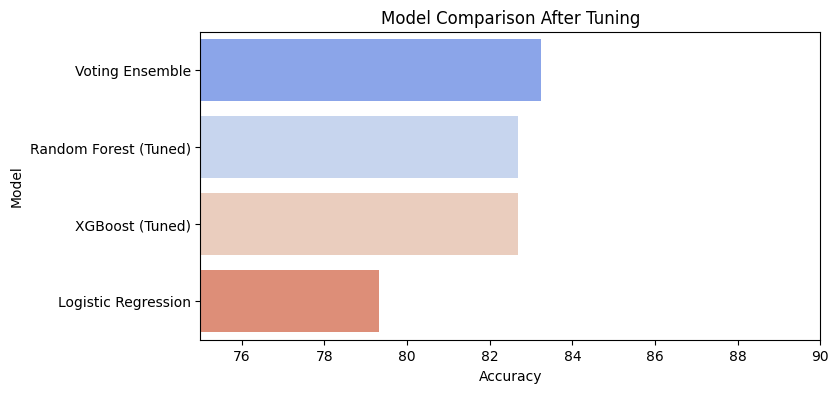


Using Voting Ensemble for final submission


In [29]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (Tuned)', 
              'XGBoost (Tuned)', 'Voting Ensemble'],
    'Accuracy': [lr_acc*100, rf_tuned_acc*100, 
                 xgb_tuned_acc*100, voting_acc*100]
}).sort_values('Accuracy', ascending=False)

print(final_results.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(x='Accuracy', y='Model', data=final_results, palette='coolwarm',legend=False)
plt.title('Model Comparison After Tuning')
plt.xlim(75, 90)
plt.show()


best_final_model = voting  
print("\nUsing Voting Ensemble for final submission")

### Final Model Comparison

Voting Ensemble wins at 83.24% local accuracy.

Started this step at 82.68% with a basic Random Forest — tuning and 
ensembling pushed it to 83.24%. Small improvement but on a competition 
leaderboard even 0.5% can move you up significantly in rankings.

Going with the Voting Ensemble for final submission.

But before submitting — need to apply the exact same cleaning and 
feature engineering steps to the test data, then generate predictions.

In [30]:
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print("Test shape:", test.shape)
print("\nMissing values in test:")
print(test.isnull().sum())
print("\nFirst 5 rows:")
test.head()

Test shape: (418, 11)

Missing values in test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

First 5 rows:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [31]:
test_clean = test.copy()

# 1. Fill Age with median (use TRAIN median, not test median)
test_clean['Age'].fillna(df['Age'].median(), inplace=True)

# 2. Fill Fare with median (1 missing in test)
test_clean['Fare'].fillna(df['Fare'].median(), inplace=True)

# 3. Fill Embarked with mode
test_clean['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. HasCabin feature
test_clean['HasCabin'] = test_clean['Cabin'].notna().astype(int)

# 5. Drop Cabin
test_clean.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(test_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


/tmp/ipykernel_57/2323114753.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_57/2323114753.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[

In [32]:
# 1. FamilySize
test_clean['FamilySize'] = test_clean['SibSp'] + test_clean['Parch'] + 1

# 2. IsAlone
test_clean['IsAlone'] = (test_clean['FamilySize'] == 1).astype(int)

# 3. Title
test_clean['Title'] = test_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

test_clean['Title'] = test_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
test_clean['Title'] = test_clean['Title'].replace(['Mme'], 'Mrs')
test_clean['Title'] = test_clean['Title'].replace(
    ['Dr', 'Rev', 'Col', 'Major', 'Countess',
     'Sir', 'Jonkheer', 'Lady', 'Capt', 'Don', 'Dona'],
    'Rare'
)
test_clean['Title'] = test_clean['Title'].map({
    'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4
})

# 4. AgeBand
test_clean['AgeBand'] = pd.cut(test_clean['Age'],
                                bins=[0, 12, 18, 35, 60, 80],
                                labels=[0, 1, 2, 3, 4])
test_clean['AgeBand'] = test_clean['AgeBand'].astype(int)

# 5. FareBand
test_clean['FareBand'] = pd.qcut(test_clean['Fare'],
                                  q=4,
                                  labels=[0, 1, 2, 3])
test_clean['FareBand'] = test_clean['FareBand'].astype(int)

# 6. Encode Sex
test_clean['Sex'] = test_clean['Sex'].map({'male': 0, 'female': 1})

# 7. Encode Embarked
test_clean['Embarked'] = test_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Features engineered successfully")
print("Missing values:", test_clean.isnull().sum().sum())

Features engineered successfully
Missing values: 0


Selecting same features as training 

In [33]:
# must be exact same columns as X_train
X_test_final = test_clean[['Pclass', 'Sex', 'Embarked', 'FamilySize', 
                             'HasCabin', 'Title', 'IsAlone', 
                             'AgeBand', 'FareBand']]

print("Test features shape:", X_test_final.shape)
print("\nAny missing values:", X_test_final.isnull().sum().sum())
print("\nFirst 5 rows:")
X_test_final.head()

Test features shape: (418, 9)

Any missing values: 0

First 5 rows:


,Pclass,Sex,Embarked,FamilySize,HasCabin,Title,IsAlone,AgeBand,FareBand
0,3,0,2,1,0,0,1,2,0
1,3,1,0,2,0,2,0,3,0
2,2,0,2,1,0,0,1,4,1
3,3,0,0,1,0,0,1,2,1
4,3,1,0,3,0,2,0,2,1


In [34]:
# use our best model — voting ensemble
predictions = voting.predict(X_test_final)

print("Predictions shape:", predictions.shape)
print("Sample predictions:", predictions[:10])
print("\nSurvived count:", predictions.sum())
print("Died count:", (predictions == 0).sum())

Predictions shape: (418,)
Sample predictions: [0 1 0 0 1 0 1 0 1 0]

Survived count: 157
Died count: 261


In [35]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)

print("Submission file created!")
print("\nShape:", submission.shape)
print("\nFirst 10 rows:")
print(submission.head(10))
print("\nSurvived distribution:")
print(submission['Survived'].value_counts())

Submission file created!

Shape: (418, 2)

First 10 rows:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Survived distribution:
Survived
0    261
1    157
Name: count, dtype: int64


In [36]:
# reload and verify the file looks correct
verify = pd.read_csv('submission.csv')

print("Shape:", verify.shape)
print("\nColumn names:", verify.columns.tolist())
print("\nAny missing values:", verify.isnull().sum().sum())
print("\nUnique values in Survived:", verify['Survived'].unique())
print("\nFirst 5 rows:")
verify.head()

Shape: (418, 2)

Column names: ['PassengerId', 'Survived']

Any missing values: 0

Unique values in Survived: [0 1]

First 5 rows:


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


<Figure size 600x500 with 0 Axes>

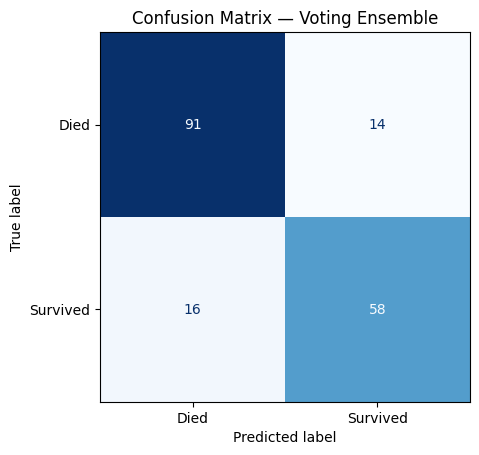

From the confusion matrix:
True Negatives  (correctly predicted death)    : 91
False Positives (said survived, actually died) : 14
False Negatives (said died, actually survived) : 16
True Positives  (correctly predicted survival) : 58


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# get predictions from best model (voting ensemble)
y_pred = voting.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Voting Ensemble')
plt.show()

print("From the confusion matrix:")
print(f"True Negatives  (correctly predicted death)    : {cm[0][0]}")
print(f"False Positives (said survived, actually died) : {cm[0][1]}")
print(f"False Negatives (said died, actually survived) : {cm[1][0]}")
print(f"True Positives  (correctly predicted survival) : {cm[1][1]}")

   Metric    Score
 Accuracy 0.832402
 F1 Score 0.794521
Precision 0.805556
   Recall 0.783784


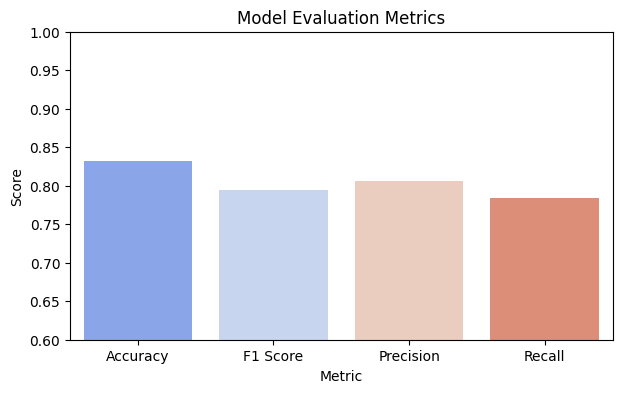

In [38]:
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Score': [accuracy, f1, precision, recall]
})

print(metrics_df.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(x='Metric', y='Score', 
            hue='Metric', data=metrics_df, 
            palette='coolwarm', legend=False)
plt.title('Model Evaluation Metrics')
plt.ylim(0.6, 1.0)
plt.show()

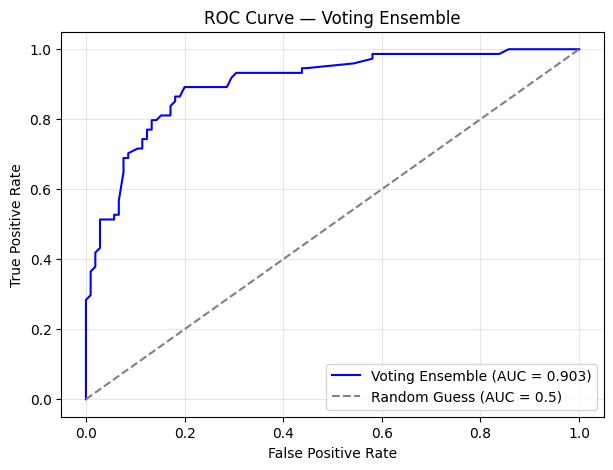

ROC-AUC Score: 0.9027


In [39]:
# get probabilities instead of just 0/1 predictions
y_prob = voting.predict_proba(X_test)[:, 1]

# calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', 
         label=f'Voting Ensemble (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='grey', 
         linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Voting Ensemble')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

In [41]:
# evaluate all 3 models together
model_names = ['Logistic Regression', 'Random Forest', 
               'XGBoost', 'Voting Ensemble']

model_objects = [
    LogisticRegression(max_iter=1000).fit(X_train, y_train),
    best_rf,
    best_xgb,
    voting
]

results_full = []
for name, model in zip(model_names, model_objects):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    results_full.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

results_full_df = pd.DataFrame(results_full)
print(results_full_df.to_string(index=False))

              Model  Accuracy       F1  Precision   Recall  ROC-AUC
Logistic Regression  0.793296 0.748299   0.753425 0.743243 0.894208
      Random Forest  0.826816 0.783217   0.811594 0.756757 0.891763
            XGBoost  0.826816 0.786207   0.802817 0.770270 0.894852
    Voting Ensemble  0.832402 0.794521   0.805556 0.783784 0.902703


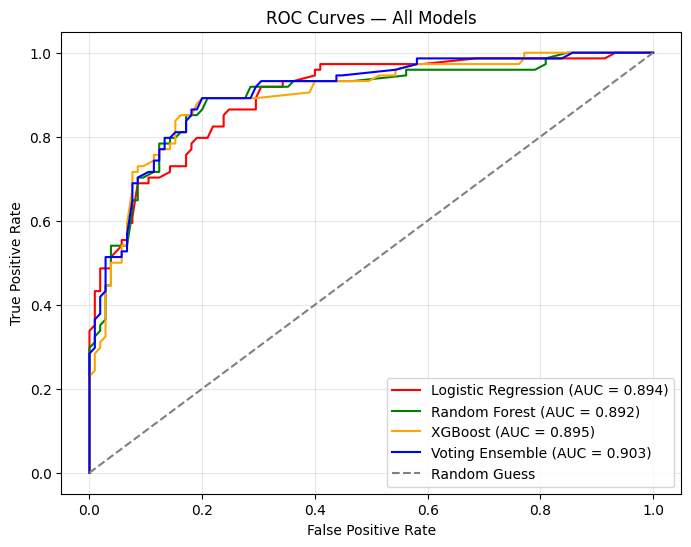

In [42]:
plt.figure(figsize=(8, 6))

colors = ['red', 'green', 'orange', 'blue']

for (name, model), color in zip(zip(model_names, model_objects), colors):
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, 
             label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'grey', linestyle='--', 
         label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()